### Example 3.4 &mdash; Linear Model with Three Gaussian Inputs

This notebook reproduces Example 3.4 from Iooss &amp; Prieur (2019) [1]:
a linear model with three correlated Gaussian inputs.  
The model is simply the sum of its inputs,

$$
Y = X_1 + X_2 + X_3, \qquad
\mathbf{X} \sim \mathcal{N}(\mathbf{0}, \Sigma),
$$

where different correlation structures $\Sigma$ are explored.
Because both the model and the input distribution are tractable,
analytical Shapley effects can be derived and compared with
Monte&nbsp;Carlo estimates obtained via the `mc_shapley` module.

The following cases are examined:

| Case | Structure |
|------|-----------|
| 1 | Independent: $\Sigma = I_3$ |
| 2 | Positive equicorrelation: $\rho = 0.5$ |
| 3 | Negative equicorrelation: $\rho = -0.4$ \* |
| 4 | Pairwise correlation: $\rho_{12} = 0.7$, otherwise 0 |

\* The case $\rho = -0.5$ is degenerate for $d = 3$ because
$\operatorname{Var}(Y) = 3 + 6(-0.5) = 0$; $\rho = -0.4$ is used
instead to keep a positive output variance while illustrating the
effect of negative dependence.

---
[1] Iooss, B., &amp; Prieur, C. (2019). &ldquo;Shapley effects for
sensitivity analysis with correlated inputs: comparison with Sobol&rsquo;
indices, numerical estimation and applications.&rdquo;
*International Journal for Uncertainty Quantification*, 9(5), 493&ndash;514.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import math

from shapleyx.utilities.mc_shapley import (
    MultivariateNormal,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.2


##### Model and analytical helpers

The model is $Y = X_1 + X_2 + X_3$.  
For a linear function with jointly Gaussian inputs the
Owen&ndash;Prieur covariance $v(u) = \operatorname{Cov}[f(\mathbf{X}), f(\mathbf{X}_u)]$
has a closed form (see the appendix of [1]).  We compute it
exactly, then obtain analytical Shapley effects via the
combinatorial formula.

In [2]:
def linear_model(x):
    """Linear model f(x) = x_1 + x_2 + x_3."""
    return x[0] + x[1] + x[2]


def v_analytical(u_indices, cov):
    """Closed-form v(u) for the linear-Gaussian model.

    v(u) = Cov[f(X), f(X_u)] where X ~ N(0, cov).
    """
    d = cov.shape[0]
    u = np.asarray(list(u_indices))
    if len(u) == 0:
        return 0.0
    if len(u) == d:
        return cov.sum()

    v_idx = np.setdiff1d(np.arange(d), u)
    ones_u = np.ones(len(u))
    ones_v = np.ones(len(v_idx))

    Sigma_uu = cov[np.ix_(u, u)]
    Sigma_uv = cov[np.ix_(u, v_idx)]
    Sigma_vu = cov[np.ix_(v_idx, u)]
    Sigma_vv = cov[np.ix_(v_idx, v_idx)]

    inv_Sigma_uu = np.linalg.inv(Sigma_uu)

    term1 = ones_u @ Sigma_uu @ ones_u
    term2 = 2.0 * ones_u @ Sigma_uv @ ones_v
    term3 = ones_v @ Sigma_vu @ inv_Sigma_uu @ Sigma_uv @ ones_v

    return term1 + term2 + term3


def analytical_shapley(cov):
    """Compute analytical Shapley effects for the linear-Gaussian model.

    Returns normalised effects (summing to 1).
    """
    d = cov.shape[0]
    v_cache = {}
    for k in range(d + 1):
        for subset in combinations(range(d), k):
            v_cache[frozenset(subset)] = v_analytical(subset, cov)

    sh = np.zeros(d)
    for i in range(d):
        for k in range(d):
            for subset in combinations(set(range(d)) - {i}, k):
                u = frozenset(subset)
                u_with_i = u.union({i})
                diff = v_cache[u_with_i] - v_cache[u]
                weight = (math.factorial(k) * math.factorial(d - k - 1)
                         / math.factorial(d))
                sh[i] += weight * diff

    total_var = v_cache[frozenset(range(d))]
    return sh / total_var

##### MC Shapley runner

Convenience function that calls `shapley_effects` for a given
covariance matrix and returns results as a DataFrame.

In [3]:
def mc_shapley_run(cov, N=20000, method='exhaustive', B=500,
                   random_state=42):
    """Run MC Shapley for a given covariance.

    Returns a DataFrame with effects and CI bounds.
    """
    d = cov.shape[0]
    joint = MultivariateNormal(mean=np.zeros(d), cov=cov)
    eff, sh, var, lower, upper = shapley_effects(
        linear_model, joint, N=N, method=method,
        B=B, alpha=0.05, random_state=random_state
    )
    return pd.DataFrame({
        'variable': [f'X{i+1}' for i in range(d)],
        'effect': eff,
        'lower': lower,
        'upper': upper,
    })

---
### Case&nbsp;1 &mdash; Independent Inputs

$\Sigma = I_3$.  By symmetry each variable accounts for exactly
one third of the output variance.

In [4]:
cov_indep = np.eye(3)
analytical_indep = analytical_shapley(cov_indep)
print("Analytical Shapley effects (independent):", analytical_indep)

Analytical Shapley effects (independent): [0.33333333 0.33333333 0.33333333]


In [5]:
mc_indep = mc_shapley_run(cov_indep, N=10000, B=300)
mc_indep

,variable,effect,lower,upper
0,X1,0.339823,0.326703,0.351247
1,X2,0.338215,0.326451,0.351682
2,X3,0.321962,0.309424,0.335929


---
### Case&nbsp;2 &mdash; Positive Equicorrelation ($\rho = 0.5$)

All pairs share the same positive correlation.  The joint
information inflates total variance but the Shapley allocation
remains symmetric.

In [6]:
rho = 0.5
cov_pos = np.array([
    [1.0, rho, rho],
    [rho, 1.0, rho],
    [rho, rho, 1.0],
])
analytical_pos = analytical_shapley(cov_pos)
print("Analytical Shapley effects (rho=0.5):", analytical_pos)

Analytical Shapley effects (rho=0.5): [0.33333333 0.33333333 0.33333333]


In [7]:
mc_pos = mc_shapley_run(cov_pos, N=10000, B=300)
mc_pos

,variable,effect,lower,upper
0,X1,0.337647,0.325272,0.352212
1,X2,0.328001,0.314045,0.341971
2,X3,0.334352,0.319904,0.348029


---
### Case&nbsp;3 &mdash; Negative Equicorrelation ($\rho = -0.4$)

Negative correlations reduce total variance, but the Shapley
effects of the three variables remain equal.  ($\rho = -0.5$
would make the output variance zero, so $\rho = -0.4$ is used.)

In [8]:
rho = -0.4
cov_neg = np.array([
    [1.0, rho, rho],
    [rho, 1.0, rho],
    [rho, rho, 1.0],
])
analytical_neg = analytical_shapley(cov_neg)
print("Analytical Shapley effects (rho=-0.4):", analytical_neg)

Analytical Shapley effects (rho=-0.4): [0.33333333 0.33333333 0.33333333]


In [9]:
mc_neg = mc_shapley_run(cov_neg, N=10000, B=300)
mc_neg

,variable,effect,lower,upper
0,X1,0.335388,0.324486,0.345143
1,X2,0.324508,0.313582,0.335493
2,X3,0.340104,0.329911,0.350641


---
### Case&nbsp;4 &mdash; Pairwise Correlation ($\rho_{12} = 0.7$)

Only $X_1$ and $X_2$ are correlated; $X_3$ is independent.
This breaks symmetry: $X_1$ and $X_2$ share redundant information
and therefore receive a smaller Shapley allocation than $X_3$,
which carries unique information.  (Under equicorrelation the
Shapley effects stay equal regardless of $\rho$.)

In [10]:
rho12 = 0.7
cov_pair = np.array([
    [1.0, rho12, 0.0],
    [rho12, 1.0, 0.0],
    [0.0,  0.0,  1.0],
])
analytical_pair = analytical_shapley(cov_pair)
print("Analytical Shapley effects (rho12=0.7):", analytical_pair)

Analytical Shapley effects (rho12=0.7): [0.38636364 0.38636364 0.22727273]


In [11]:
mc_pair = mc_shapley_run(cov_pair, N=20000, B=300)
mc_pair

,variable,effect,lower,upper
0,X1,0.390800,0.381411,0.401523
1,X2,0.382553,0.371496,0.392414
2,X3,0.226647,0.217814,0.236737


---
### Visual Comparison: MC Estimates vs Analytical Values

The bar chart below shows Monte&nbsp;Carlo Shapley effects (with
95&thinsp;% bootstrap confidence intervals) alongside the exact
analytical values for each correlation case.

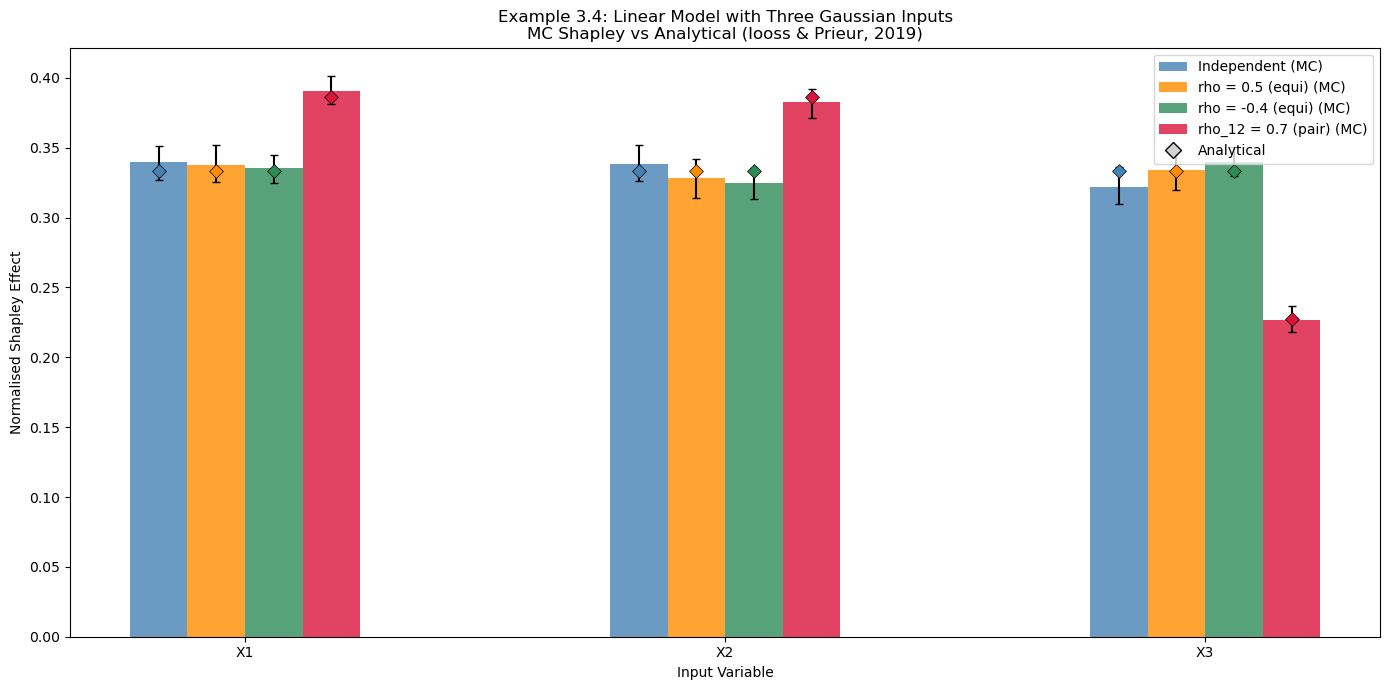

In [12]:
cases = [
    ('Independent', mc_indep, analytical_indep),
    ('rho = 0.5 (equi)', mc_pos, analytical_pos),
    ('rho = -0.4 (equi)', mc_neg, analytical_neg),
    ('rho_12 = 0.7 (pair)', mc_pair, analytical_pair),
]

n_vars = 3
n_cases = len(cases)
bar_width = 0.12
x = np.arange(n_vars)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for j, (label, mc_df, anal) in enumerate(cases):
    offset = (j - (n_cases - 1) / 2) * bar_width
    # MC bars with error bars
    bars = ax.bar(
        x + offset, mc_df['effect'], bar_width,
        yerr=[mc_df['effect'] - mc_df['lower'],
              mc_df['upper'] - mc_df['effect']],
        capsize=3, color=colors[j], alpha=0.80, label=f'{label} (MC)',
    )
    # Analytical markers
    ax.scatter(
        x + offset, anal, marker='D', color=colors[j],
        edgecolors='black', linewidths=0.5, s=50, zorder=5,
    )

# Add a dummy marker for the legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='D', color='black',
                          markerfacecolor='lightgray',
                          markeredgecolor='black', markersize=8,
                          label='Analytical', linestyle='None')]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_elements, loc='upper right')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Normalised Shapley Effect')
ax.set_title(
    'Example 3.4: Linear Model with Three Gaussian Inputs\n'
    'MC Shapley vs Analytical (Iooss & Prieur, 2019)'
)
ax.set_xticks(x)
ax.set_xticklabels(['X1', 'X2', 'X3'])
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

---
### Comparison of Exhaustive vs Permutation Methods

For the pairwise-correlation case, compare the exhaustive
(all $2^d-1$ subsets) and permutation-based approaches.

In [13]:
# Exhaustive (already computed above as mc_pair)
# Permutation
mc_pair_perm = mc_shapley_run(
    cov_pair, N=20000, method='permutation', B=300
)

comparison = pd.DataFrame({
    'Variable': mc_pair['variable'],
    'Analytical': analytical_pair,
    'Exhaustive': mc_pair['effect'],
    'Permutation': mc_pair_perm['effect'],
})
comparison['Exh. Error'] = np.abs(
    comparison['Exhaustive'] - comparison['Analytical']
)
comparison['Perm. Error'] = np.abs(
    comparison['Permutation'] - comparison['Analytical']
)
comparison

,Variable,Analytical,Exhaustive,Permutation,Exh. Error,Perm. Error
0,X1,0.386364,0.390800,0.373957,0.004436,0.012407
1,X2,0.386364,0.382553,0.389685,0.003811,0.003321
2,X3,0.227273,0.226647,0.236359,0.000626,0.009086


---
### Summary

- The MC Shapley estimates match the analytical values closely
  across all correlation structures.
- Under equicorrelation the Shapley effects remain equal,
  confirming that the method correctly captures the symmetric
  role of each variable.
- With pairwise correlation ($X_1$&ndash;$X_2$), the correlated
  pair receives a smaller allocation than the independent
  variable &mdash; illustrating how Shapley effects penalise
  redundant information.
- The permutation method yields results consistent with the
  exhaustive method at lower computational cost.

In [14]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Wed, 29 Apr 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 2.3.3
shapleyx  : 0.2

Watermark: 2.6.0

